In [1]:
import os
import sys

In [2]:
import json

with open("client_ip.json", "r") as f:
    client_ip = json.load(f)

In [ ]:
import tensorflow as tf

In [4]:
print(tf.__version__)

2.19.0


In [7]:
batch_size = 128
features = 40
input_shape = (features,2)

In [8]:
import matplotlib.pyplot as plt
import numpy as np
WINDOW=40
def lstm_vector(ts1,sizes1,ts2,sizes2,voip=False):
    #determine direction
    if voip:
        src_ts = ts1
        src_sizes = sizes1
        dst_ts = ts2
        dst_sizes = sizes2
    else:
        if ts1[0]<ts2[0]:
            src_ts = ts1
            src_sizes = sizes1
            dst_ts = ts2
            dst_sizes = sizes2
        else:
            src_ts = ts2
            src_sizes = sizes2
            dst_ts = ts1
            dst_sizes = sizes1
    array = []
    j = 0 #src
    k = 0 #dst
    min_val = min(src_ts[0],dst_ts[0])
    length = len(src_ts)+len(dst_ts)
    for i in range(40):
        if j>=len(src_ts) and k>=len(dst_ts):
            break
        if j>=len(src_ts):
            array.append([round(dst_ts[k]-min_val,6),-dst_sizes[k]])
            k+=1
        elif k >= len(dst_ts):
            array.append([round(src_ts[j]-min_val,6),src_sizes[j]]) 
            j+=1
        elif src_ts[j]<=dst_ts[k]:
            array.append([round(src_ts[j]-min_val,6),src_sizes[j]]) 
            j+=1
        else:
            array.append([round(dst_ts[k]-min_val,6),-dst_sizes[k]])
            k+=1
    # for i in range(WINDOW-length):
    #      array.append([0,0])
    array = np.array(array)
    X = array.reshape(-1,2)
    return X

In [9]:
WINDOW=50
def seq_50(ts1,sizes1,ts2,sizes2):
    #determine direction
    if ts1[0]<ts2[0]:
        src_ts = ts1
        src_sizes = sizes1
        dst_ts = ts2
        dst_sizes = sizes2
    else:
        src_ts = ts2
        src_sizes = sizes2
        dst_ts = ts1
        dst_sizes = sizes1
    array = []
    j = 0 #src
    k = 0 #dst
    min_val = min(src_ts[0],dst_ts[0])
    for i in range(WINDOW):
        if j>=len(src_ts) and k>=len(dst_ts):
            break
        if j>=len(src_ts):
            array.append([round(dst_ts[k]-min_val,6),-dst_sizes[k]])
            k+=1
        elif k >= len(dst_ts):
            array.append([round(src_ts[j]-min_val,6),src_sizes[j]]) 
            j+=1
        elif src_ts[j]<=dst_ts[k]:
            array.append([round(src_ts[j]-min_val,6),src_sizes[j]]) 
            j+=1
        else:
            array.append([round(dst_ts[k]-min_val,6),-dst_sizes[k]])
            k+=1
    for i in range(WINDOW-len(array)):
         array.append([0,0])
    array = np.array(array)
    X = array.reshape(-1,2)
    return X

In [10]:
def check_strings_in_classname(classname):
    keywords = {
    "web": 0, "video": 1, "social": 2, "email": 3,"voip":4,"chat":5,"gaming":6,"docs":7
    }
    for keyword in keywords:
        if keyword in classname:
            return keywords[keyword] 
    return None

In [11]:
# check_path = os.path.join(checkpoint_dir, MODEL_NAME + 'pseudo_labeled_binary_lstm_acc.weights.h5')
# pipeline.named_steps['model'].load_weights(check_path) 

In [12]:
X_train = []
y_train = []
voip = []
gaming = []
web = []
video = []
social = []
email = []
doc = []
microsoft = []
chat = []
background = []

In [13]:
path2 = os.path.abspath('..')

In [14]:
import os
import csv
import tensorflow as tf

folder_path = path2+"/labeled_train"

In [15]:
import json
def traffic_csv_converter(file_path):
    X_train = []
    y_train = []
    with open(file_path, 'r') as csv_file:
        reader = csv.reader(csv_file)
        filename = os.path.splitext(os.path.basename(file_path))[0]
        flow_val = {}
        class_val = {}
        paired_keys = set()
        for i, row in enumerate(reader):
            class_name = row[0]
            src_ip = row[1]
            src_port = row[2]
            dst_ip = row[3]
            dst_port = row[4]
            length = int(row[7])
            ts = np.array(row[8:8+length], dtype=float)
            sizes = np.array(row[9+length:], dtype=int)
            key = (src_ip, src_port, dst_ip, dst_port)
            reverse_key = (dst_ip, dst_port, src_ip, src_port)
            if reverse_key in flow_val:
                # Found the reverse flow
                opposite_ts, opposite_sizes = flow_val.pop(reverse_key)
                paired_keys.add(key)
                paired_keys.add(reverse_key)
                if len(opposite_ts) + len(ts) < 40: #flow too small
                    continue
                if "voip" in file_path and class_name =="voip":
                    if reverse_key[0] in client_ip:
                        src_ts, src_sizes = opposite_ts, opposite_sizes
                        dst_ts, dst_sizes = ts, sizes
                    else:
                        src_ts, src_sizes = ts, sizes
                        dst_ts, dst_sizes = opposite_ts, opposite_sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes,True)
                    v = seq_50(src_ts, src_sizes, dst_ts, dst_sizes)
                else:
                    src_ts, src_sizes = opposite_ts, opposite_sizes
                    dst_ts, dst_sizes = ts, sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes)
                    v = seq_50(src_ts, src_sizes, dst_ts, dst_sizes)
                if "voip" in file_path:
                    voip.append(v)
                    y_train.append(6)
                elif "gaming" in file_path:
                    gaming.append(v)
                    y_train.append(7)
                elif "web" in file_path:
                    web.append(v)
                    y_train.append(0)
                elif "video" in file_path:
                    video.append(v)
                    y_train.append(1)
                elif "social" in file_path:
                    social.append(v)
                    y_train.append(2)
                elif "email" in file_path:
                    email.append(v)
                    y_train.append(3)
                elif "doc" in file_path:
                    doc.append(v)
                    y_train.append(4)
                elif "chat" in file_path:
                    chat.append(v)
                    y_train.append(5)
                X_train.append(x)
            else:
                # Save forward direction flow
                flow_val[key] = (ts, sizes)
                class_val[key] = class_name
    for key, value in flow_val.items():
        if key[1] == "5353":
            continue
        if len(value[0]) >= 40:
            if "voip" in file_path:
                ts = value[0][:40]
                sizes = value[1][:40]
                if key[0] in client_ip:
                    sizes = value[1][:40]
                else:
                    sizes = -value[1][:40]
                v = np.stack((ts, sizes), axis=1)
                X_train.append(v)
                y_train.append(6)
                ts = value[0][:50]
                if key[0] in client_ip:
                    sizes = value[1][:50]
                else:
                    sizes = -value[1][:50]
                if len(ts)<50:
                    pad = 50 - len(ts)
                    ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                    
                v = np.stack((ts, sizes), axis=1)
                voip.append(v)
            elif "gaming" in file_path:
                ts = value[0][:40]
                sizes = value[1][:40]
                v = np.stack((ts, sizes), axis=1)
                X_train.append(v)
                y_train.append(7)
                ts = value[0][:50]
                sizes = value[1][:50]
                if len(ts)<50:
                    pad = 50 - len(ts)
                    ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                v = np.stack((ts, sizes), axis=1)
                gaming.append(v)
            
            
    return X_train, y_train
def iterate_over_files_in_directory(directory):
    for file_name in os.listdir(directory):
        if file_name.endswith(".csv"):  # You can adjust the file extension if needed
            file_path = os.path.join(directory, file_name)
            yield file_path


In [16]:
docs_path = folder_path + "/docs"
for file_path in iterate_over_files_in_directory(docs_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
web_path = folder_path + "/web"
for file_path in iterate_over_files_in_directory(web_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
chat_path = folder_path + "/chat"
for file_path in iterate_over_files_in_directory(chat_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
social_path = folder_path + "/social"
for file_path in iterate_over_files_in_directory(social_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
video_path = folder_path + "/video"
for file_path in iterate_over_files_in_directory(video_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
voip_path = folder_path + "/voip"
for file_path in iterate_over_files_in_directory(voip_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
gaming_path = folder_path + "/gaming"
for file_path in iterate_over_files_in_directory(gaming_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
email_path = folder_path + "/email"
for file_path in iterate_over_files_in_directory(email_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)

In [17]:
import numpy as np

In [18]:
X_dataset = np.array(X_train)

In [19]:
y_dataset = np.array(y_train)

In [20]:
from collections import Counter
counter = Counter(y_dataset)
counts = [counter.get(i, 0) for i in range(10)]

In [21]:
max_val = max(counts)

In [22]:
max_val

20832

In [23]:
counts

[20832, 2475, 1522, 2791, 336, 170, 1175, 1006, 0, 0]

In [24]:
def translation(X):
    arrival_times = X
    n,time_steps,features = arrival_times.shape
    for i in range(n):
        threshold_indices = [2,4,6,8,10] 
        max_n =np.random.choice(threshold_indices) 
        n = np.random.randint(1, max_n + 1)  # Shift 1 to `max_n` packets
        t = np.random.randint(0, 40) 
        direction = np.random.choice(['left', 'right'])
        if direction == 'left':
            total_length = arrival_times.shape[1]
            start_index = t-n
            if start_index < 0: 
                valid_portion = arrival_times[i, t - start_index:50]
                assigned_value = valid_portion.shape[0]
                arrival_times[i, 0:assigned_value] = valid_portion
                arrival_times[i, assigned_value+1:] = 0 
            else:
                valid_portion = arrival_times[i, t:(50)]
                assigned_value = arrival_times[i, start_index:50].shape
                zeros = np.zeros((assigned_value[0]-valid_portion.shape[0],2))
                arrival_times[i, start_index:50] = np.concatenate((valid_portion, zeros))  # bounded to the right by 50
            
        else:
            t_val = arrival_times[i, t] 
            last_index = min(t + n, 40) 
            first_val = min(last_index + n, 40)  
            num_to_shift = last_index - t  
            available_space = 40 - first_val 
            if num_to_shift > 0:
                shift_amount = min(num_to_shift, available_space)
                arrival_times[i, first_val:first_val + shift_amount] = arrival_times[i, t:t + shift_amount]
            arrival_times[i, t:last_index] = t_val
    return arrival_times

In [25]:
voip = np.array(voip)
gaming = np.array(gaming)
web = np.array(web)
video = np.array(video)
social = np.array(social)
email = np.array(email)
doc = np.array(doc)
microsoft = np.array(microsoft)
chat = np.array(chat)
background = np.array(background)

In [26]:
for i in range(8):
    if i == 0:
        sample = web
    elif i == 1:
        sample = video
    elif i == 2:
        sample = social
    elif i == 3:
        sample = email
    elif i == 4:
        sample = doc
    elif i == 5:
        sample = chat
    elif i == 6:
        sample = voip
    elif i == 7:
        sample = gaming
    indices = tf.range(sample.shape[0])
    value = len(sample)
    print(value)
    if value == max_val:
        continue
    sampled_indices = np.random.choice(indices, max_val-value, replace=True)
    sampled_X = sample[sampled_indices]
    augmented = translation(sampled_X)
    augmented = augmented[:, :40, :]
    X_dataset = np.vstack((X_dataset,augmented))
    y = np.array([i]*(max_val-value))
    y_dataset = np.concatenate((y_dataset,y))

W0000 00:00:1753808640.291528  807784 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


20832
2475
1522
2791
336
170
1175
1006


In [27]:
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_dataset, y_dataset, test_size=0.2, random_state=42)

In [28]:
y_train = to_categorical(y_train, num_classes=8)
y_val = to_categorical(y_val, num_classes=8)

In [16]:
num_classes = 8

In [17]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.callbacks import TensorBoard, ModelCheckpoint
from keras.models import Sequential
from keras.layers import InputLayer,Conv1D, MaxPooling1D, Flatten, Dense, Dropout,LSTM,BatchNormalization,Bidirectional,LayerNormalization
from keras import backend as K
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from keras.metrics import top_k_categorical_accuracy
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K
from tensorflow.keras import layers, models
path = os.path.abspath('')


def precision(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def recall(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def f1_score(y_true, y_pred):
    prec = precision(y_true, y_pred)
    rec = recall(y_true, y_pred)
    return 2 * ((prec * rec) / (prec + rec))

# def top_2_categorical_accuracy(y_true, y_pred):
#     return top_k_categorical_accuracy(y_true, y_pred, k=2)

# Custom transformer to transpose data

# Set the ratio for the train-test split


# Create a scikit-learn pipeline
def build_lstm_classifier(input_shape, num_classes, 
                          encoder_units=(128, 64), 
                          projection_dim=64, 
                          dropout_rate=0.1):
    """
    Builds an LSTM-based classifier.

    Args:
      input_shape: tuple, e.g. (timesteps, features)
      num_classes: int, number of target classes
      encoder_units: tuple of two ints, the hidden sizes of the two Bi‑LSTM layers
      projection_dim: int, size of the intermediate dense ('representation') layer
      dropout_rate: float, dropout after the second LSTM

    Returns:
      A tf.keras.Model ready for compilation.
    """
    inputs = layers.Input(shape=input_shape, name="input_sequence")

    # First Bi‑LSTM block
    x = layers.Bidirectional(
        layers.LSTM(encoder_units[0], return_sequences=True),
        name="bi_lstm_1"
    )(inputs)
    x = layers.LayerNormalization(name="ln_1")(x)

    # Second Bi‑LSTM block
    x = layers.Bidirectional(
        layers.LSTM(encoder_units[1], return_sequences=False),
        name="bi_lstm_2"
    )(x)
    x = layers.LayerNormalization(name="ln_2")(x)
    x = layers.Dropout(dropout_rate, name="dropout")(x)

    # Bottleneck / projection
    h = layers.Dense(
        projection_dim, 
        activation="gelu", 
        name="representation"
    )(x)

    # Classification head
    outputs = layers.Dense(
        num_classes, 
        activation="softmax", 
        name="classifier"
    )(h)

    return models.Model(inputs, outputs, name="lstm_classifier")

# Example usage:
timesteps, features = 40, 2       # adjust to your data
num_classes = 8                 # set to your number of classes
model = build_lstm_classifier(
    input_shape=(timesteps, features),
    num_classes=num_classes
)
# Compile the model with custom metrics


# Set up callbacks
checkpoint_dir = os.path.abspath('')+"/tensorboard"
log_dir = os.path.abspath('') + "/log"
MODEL_NAME = "checkpoint"
check_path = os.path.join(checkpoint_dir, MODEL_NAME + 'lstm_loss.weights.h5')
tensorboard = TensorBoard(log_dir='./Graph', histogram_freq=1, write_graph=True,
                          write_images=True)
checkpointer_loss = ModelCheckpoint(filepath=check_path, verbose=1, save_best_only=True,
                                     save_weights_only=True)
checkpointer_acc = ModelCheckpoint(monitor='val_f1_score', filepath= os.path.join(checkpoint_dir, MODEL_NAME + 'lstm_acc.weights.h5'), verbose=1,
                                    save_best_only=True, save_weights_only=True,mode='max')
tensorboard.set_model(model)

early_stopping = EarlyStopping(monitor='val_f1_score', patience=50, restore_best_weights=True,mode='max')



W0000 00:00:1753834230.722924  416119 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [18]:
model.compile(loss='categorical_crossentropy',
                                      optimizer='adam',
                                      metrics=['accuracy', f1_score, precision, recall])

In [ ]:
history = model.fit(X_train, y_train, epochs=500, batch_size=batch_size, callbacks=[early_stopping,tensorboard, checkpointer_loss, checkpointer_acc],
         validation_data=(X_val, y_val))

Epoch 1/500
 323/1042 ━━━━━━━━━━━━━━━━━━━━ 1:34 132ms/step - accuracy: 0.3789 - f1_score: nan - loss: 1.6424 - precision: 0.6463 - recall: 0.1698

In [21]:
# model = pipeline.named_steps['model']
# model.build(input_shape=(None, 50, 2)) 

In [20]:
from tensorflow.keras import Input
check_path = os.path.join(checkpoint_dir, MODEL_NAME + 'lstm_acc.weights.h5')
# input_shape = (50, 2)

# _ = pipeline.named_steps['model']( Input(shape=input_shape) )

# 2) Now that all weights exist, load them
model.load_weights(check_path)

# 3) (Optional) verify
# pipeline.named_steps['model'].summary()

In [21]:
X_test = []
y_test = []

In [22]:
import csv
def test_traffic_csv_converter(file_path):
    X_train = []
    y_train = []
    with open(file_path, 'r') as csv_file:
        reader = csv.reader(csv_file)
        filename = os.path.splitext(os.path.basename(file_path))[0]
        flow_val = {}
        class_val = {}
        paired_keys = set()
        for i, row in enumerate(reader):
            class_name = row[0]
            src_ip = row[1]
            src_port = row[2]
            dst_ip = row[3]
            dst_port = row[4]
            length = int(row[7])
            ts = np.array(row[8:8+length], dtype=float)
            sizes = np.array(row[9+length:], dtype=int)
            key = (src_ip, src_port, dst_ip, dst_port)
            reverse_key = (dst_ip, dst_port, src_ip, src_port)
            if reverse_key in flow_val:
                # Found the reverse flow
                opposite_ts, opposite_sizes = flow_val.pop(reverse_key)
                paired_keys.add(key)
                paired_keys.add(reverse_key)
                if len(opposite_ts) + len(ts) < 40: #flow too small
                    continue
                if "voip" in file_path and class_name =="voip":
                    if reverse_key[0] in client_ip:
                        src_ts, src_sizes = opposite_ts, opposite_sizes
                        dst_ts, dst_sizes = ts, sizes
                    else:
                        src_ts, src_sizes = ts, sizes
                        dst_ts, dst_sizes = opposite_ts, opposite_sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes,True)
                    v = seq_50(src_ts, src_sizes, dst_ts, dst_sizes)
                else:
                    src_ts, src_sizes = opposite_ts, opposite_sizes
                    dst_ts, dst_sizes = ts, sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes)
                    v = seq_50(src_ts, src_sizes, dst_ts, dst_sizes)
                if "voip" in file_path:
                    voip.append(v)
                    y_train.append(6)
                elif "gaming" in file_path:
                    gaming.append(v)
                    y_train.append(7)
                elif "web" in file_path:
                    web.append(v)
                    y_train.append(0)
                elif "video" in file_path:
                    video.append(v)
                    y_train.append(1)
                elif "social" in file_path:
                    social.append(v)
                    y_train.append(2)
                elif "email" in file_path:
                    email.append(v)
                    y_train.append(3)
                elif "doc" in file_path:
                    doc.append(v)
                    y_train.append(4)
                elif "chat" in file_path:
                    chat.append(v)
                    y_train.append(5)
                X_train.append(x)
            else:
                # Save forward direction flow
                flow_val[key] = (ts, sizes)
                class_val[key] = class_name
    for key, value in flow_val.items():
        if key[1] == "5353":
            continue
        if len(value[0]) >= 40:
            if "voip" in file_path:
                ts = value[0][:40]
                sizes = value[1][:40]
                if key[0] in client_ip:
                    sizes = value[1][:40]
                else:
                    sizes = -value[1][:40]
                v = np.stack((ts, sizes), axis=1)
                X_train.append(v)
                y_train.append(6)
                
#                 ts = value[0][:50]
#                 if key[0] in client_ip:
#                     sizes = value[1][:50]
#                 else:
#                     sizes = -value[1][:50]
#                 if len(ts)<50:
#                     pad = 50 - len(ts)
#                     ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
#                     sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                    
#                 v = np.stack((ts, sizes), axis=1)
#                 if class_val[key] == "voip":
#                     voip.append(v)
            elif "gaming" in file_path:
                ts = value[0][:40]
                sizes = value[1][:40]
                v = np.stack((ts, sizes), axis=1)
                X_train.append(v)
                y_train.append(7)
                # ts = value[0][:50]
                # sizes = value[1][:50]
                # if len(ts)<50:
                #     pad = 50 - len(ts)
                #     ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                #     sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                # v = np.stack((ts, sizes), axis=1)
                # gaming.append(v)
            else:
                print("unidirectional")
            
            
    return X_train, y_train

In [23]:
folder_path = os.path.abspath('..')+"/labeled_test"
docs_path = folder_path + "/docs"
for file_path in iterate_over_files_in_directory(docs_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
web_path = folder_path + "/web"
for file_path in iterate_over_files_in_directory(web_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
chat_path = folder_path + "/chat"
for file_path in iterate_over_files_in_directory(chat_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
social_path = folder_path + "/social"
for file_path in iterate_over_files_in_directory(social_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
video_path = folder_path + "/video"
for file_path in iterate_over_files_in_directory(video_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
voip_path = folder_path + "/voip"
for file_path in iterate_over_files_in_directory(voip_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
gaming_path = folder_path + "/gaming"
for file_path in iterate_over_files_in_directory(gaming_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
email_path = folder_path + "/email"
for file_path in iterate_over_files_in_directory(email_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)

In [24]:
X_test = np.array(X_test)

In [25]:
y_test=np.array(y_test)
y_test.shape

(11264,)

In [26]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step


In [27]:
y_test=np.array(y_test)
y_test_categorical = y_test

In [28]:
def weighted_accuracy(y_true, y_pred, flow_sizes):
    total_flow_size = sum(flow_sizes)
    weighted_acc = 0
    for i, flow_size in enumerate(flow_sizes):
        if y_true[i] == y_pred[i]:
            prediction = 1
        else:
            prediction = 0
        weighted_acc += flow_size * prediction
    weighted_acc /= total_flow_size
    
    return weighted_acc

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# weighted_accuracy = round(weighted_accuracy(y_test_categorical, y_pred, flow_sizes), 2)
macro_f1 = round(f1_score(y_test_categorical, y_pred, average='macro'), 2)
accuracy = round(accuracy_score(y_test_categorical, y_pred), 2)
average_f1 = round(f1_score(y_test_categorical, y_pred, average='weighted'), 2)
# precision = precision_score(y_test_categorical, y_pred, average=None)
# recall = recall_score(y_test_categorical, y_pred, average=None)
# f1 = f1_score(y_test_categorical, y_pred, average=None)
conf_matrix = confusion_matrix(y_test_categorical, y_pred)

# Print or use the evaluation metrics as needed
# print(f'Weighted Average Accuracy: {weighted_accuracy}')
print(f'Macro Average F1 Score: {macro_f1}')
print(f'Accuracy: {accuracy}')
print(f'Weighted Average F1 Score: {average_f1}')
# print(f'Precision: {precision}')
# print(f'Recall: {recall}')
# print(f'F1 Score: {f1}')
# print(f'Confusion Matrix:\n{conf_matrix}')

Macro Average F1 Score: 0.72
Accuracy: 0.79
Weighted Average F1 Score: 0.81


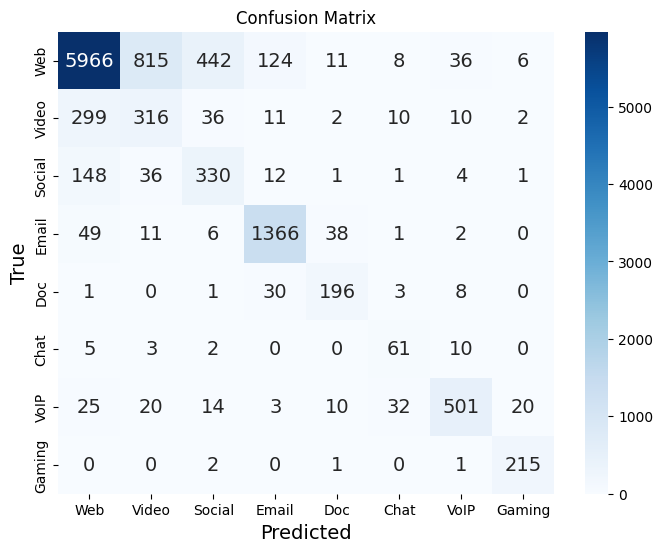

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Chat","VoIP","Gaming"]
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws={"size": 14})
# ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
# for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('bilstm_session.png', dpi=300, bbox_inches='tight')
plt.show()

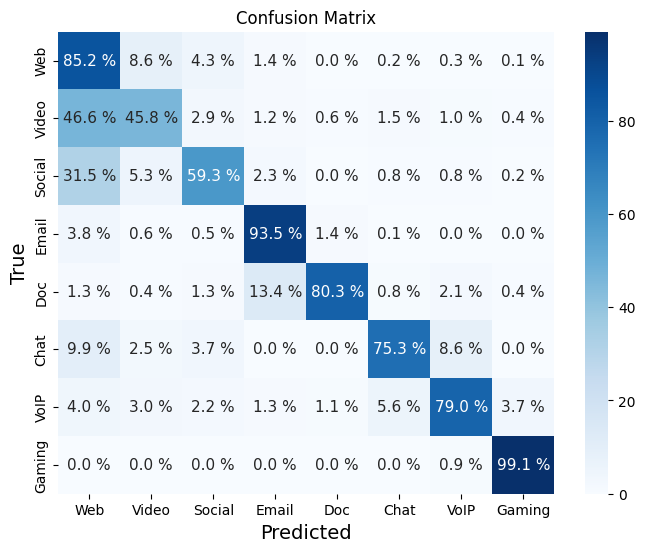

In [31]:
conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Chat","VoIP","Gaming"]
# Plot confusion matrix
plt.figure(figsize=(8, 6))
annot_kws = {"size": 11}
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_kws)
for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)  
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('40 >40 confusion_matrixpercent.png', dpi=300, bbox_inches='tight')
plt.show()

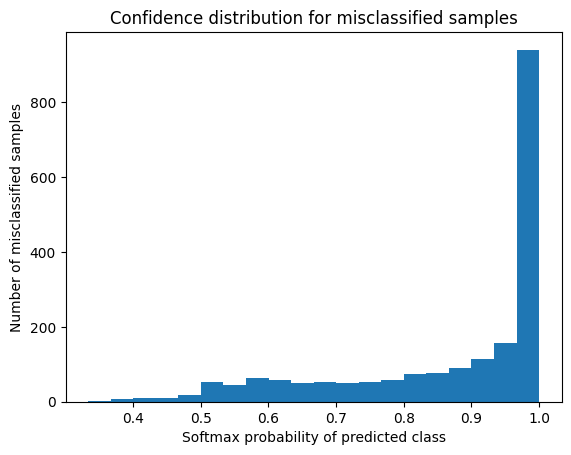

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# mask for misclassified samples
mask = (y_pred != y_test)

# pick out the probability that the model assigned to its (wrong) prediction
mis_probs = y_pred_prob[mask, y_pred[mask]]

# plot a histogram of those confidences
plt.figure()
plt.hist(mis_probs, bins=20)
plt.xlabel('Softmax probability of predicted class')
plt.ylabel('Number of misclassified samples')
plt.title('Confidence distribution for misclassified samples')
plt.show()

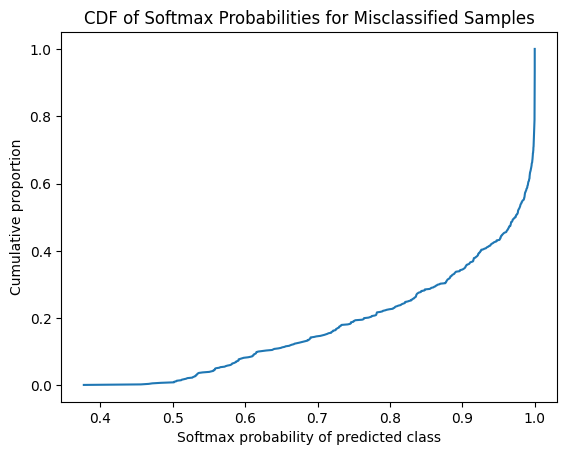

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Select only the misclassified samples
mask = (y_pred != y_test)

# 2) Grab the softmax score assigned to the (wrong) predicted class
mis_probs = y_pred_prob[mask, y_pred[mask]]

# 3) Sort and build the CDF
sorted_probs = np.sort(mis_probs)
cdf = np.arange(1, len(sorted_probs) + 1) / len(sorted_probs)

# 4) Plot
plt.figure()
plt.plot(sorted_probs, cdf)
plt.xlabel('Softmax probability of predicted class')
plt.ylabel('Cumulative proportion')
plt.title('CDF of Softmax Probabilities for Misclassified Samples')
plt.show()

In [59]:
y_pred = np.argmax(y_pred_prob, axis=1)  # shape (N,)

# — Step 1: Compute the “max confidence” per sample — #
# This finds, for each sample i, the highest softmax‐score across all classes.
confidences = np.max(y_pred_prob, axis=1)  # shape: (N,)

# — Step 2: Build a mask for “keep only if max confidence ≥ 0.9” — #
mask_high_conf = confidences >= 0.9  # shape: (N,), dtype=bool

# — Step 3: Filter your arrays by that mask — #
# If you want to keep only rows with confidence ≥ 0.9 in y_pred_prob:
y_pred_prob_filtered = y_pred_prob[mask_high_conf]  # shape: (__ , C)

# If you also want to keep only those predicted‐class indices:
y_pred_filtered = y_pred[mask_high_conf]

In [60]:
y_test_filtered = y_test[mask_high_conf]

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# weighted_accuracy = round(weighted_accuracy(y_test_categorical, y_pred, flow_sizes), 2)
macro_f1 = round(f1_score(y_test_filtered, y_pred_filtered, average='macro'), 2)
accuracy = round(accuracy_score(y_test_filtered, y_pred_filtered), 2)
average_f1 = round(f1_score(y_test_filtered, y_pred_filtered, average='weighted'), 2)
# precision = precision_score(y_test_categorical, y_pred, average=None)
# recall = recall_score(y_test_categorical, y_pred, average=None)
# f1 = f1_score(y_test_categorical, y_pred, average=None)
conf_matrix = confusion_matrix(y_test_filtered, y_pred_filtered)

# Print or use the evaluation metrics as needed
# print(f'Weighted Average Accuracy: {weighted_accuracy}')
print(f'Macro Average F1 Score: {macro_f1}')
print(f'Accuracy: {accuracy}')
print(f'Weighted Average F1 Score: {average_f1}')
# print(f'Precision: {precision}')
# print(f'Recall: {recall}')
# print(f'F1 Score: {f1}')
# print(f'Confusion Matrix:\n{conf_matrix}')

Macro Average F1 Score: 0.87
Accuracy: 0.96
Weighted Average F1 Score: 0.96


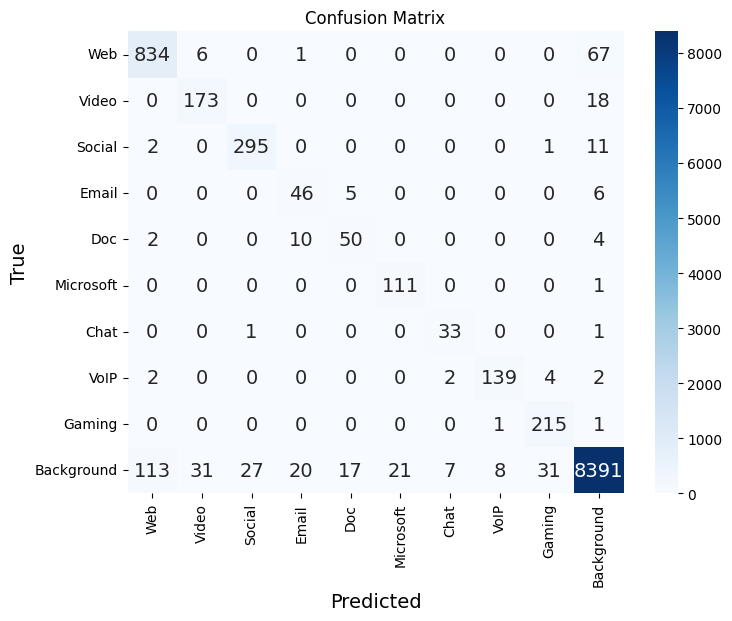

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws={"size": 14})
# ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
# for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('40 >40 confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

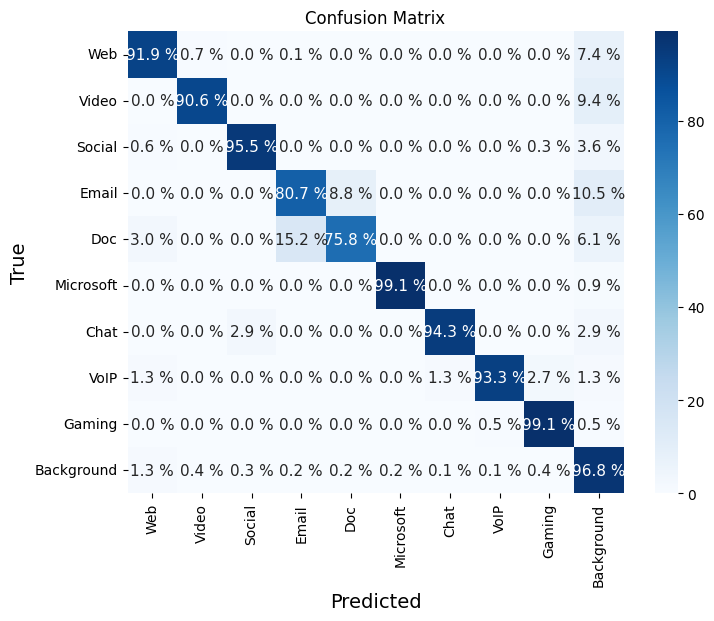

In [63]:
conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
annot_kws = {"size": 11}
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_kws)
for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)  
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('40 >40 confusion_matrixpercent.png', dpi=300, bbox_inches='tight')
plt.show()